In [68]:
# Gustavo Cruz 22779
# Javier Chen 22153

# Imports
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path
import openeo
import folium
import numpy as np
import rasterio
from rasterio.plot import reshape_as_image
import tempfile
from PIL import Image
import io
import base64

In [50]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [51]:
# Arriba hay que autenticar con el url que te da el notebook, se ingresan las credenciales y se cierra la pestaña cuando termines

# Ejercicio 2

with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

print("bbox_amatitlan:", bbox_amatitlan)
print("bbox_atitlan:", bbox_atitlan)

# Ejercicio 3
START_DATE = "2025-01-01" 
END_DATE = "2025-08-01"

bbox_amatitlan: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}
bbox_atitlan: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}


In [52]:
# Ejercicio 4 y 5
def load_cube(bbox):
    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[START_DATE, END_DATE],
        bands=["B02", "B03", "B04", "B08"]
    )
    
    # Filtrar para obtener máximo 4 imágenes por mes
    filtered_cube = cube.aggregate_temporal_period(
        period="month",
        reducer="first"
    ).filter_temporal([START_DATE, END_DATE])
    
    return filtered_cube

def ndci(cube):
    b5 = cube.band("B05")
    b4 = cube.band("B04")
    return (b5 - b4) / (b5 + b4)

def process_and_download_ndci(bbox, out_folder):
    print(f"Procesando {out_folder}...")
    cube = load_cube(bbox)
    
    os.makedirs(out_folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(out_folder)
    print(f"Descarga completada en {out_folder}")
    return out_folder

cube = load_cube(bbox_amatitlan)
print(cube.metadata)

# Ejecutar para ambos lagos
process_and_download_ndci(bbox_amatitlan, "./imagenes/NDCI_Amatitlan")
process_and_download_ndci(bbox_atitlan, "./imagenes/NDCI_Atitlan")


# Estas van a ser funciones auxiliares para presentar mejor la data despues
def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def download_cube(cube, folder):
    os.makedirs(folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(folder)
    return folder

# Como tarda un monton, ahorita solo descarga 1 imagen por mes, para aumentarla se puede modificar la funcion de load_cube

CollectionMetadata({'spatial': {'bbox': [[-180, -56, 180, 83]]}, 'temporal': {'interval': [['2015-07-04T00:00:00Z', None]]}} - ['B02', 'B03', 'B04', 'B08'] - ['bands', 't', 'x', 'y'])
Procesando ./imagenes/NDCI_Amatitlan...
0:00:00 Job 'j-2508102145264032818ab756fe15628c': send 'start'
0:00:13 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:18 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:25 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:33 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:43 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:00:56 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:11 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:30 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:55 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:02:25 Job 'j-2508102145264032818ab756fe15628c': running (p

                mean
date                
2025-01-01  0.124396
2025-02-01  0.102402
2025-03-01  0.030008
2025-04-01  0.033237
2025-05-01 -0.004774
                mean
date                
2025-01-01  0.129143
2025-02-01  0.167267
2025-03-01  0.072307
2025-04-01  0.120135
2025-05-01  0.029860


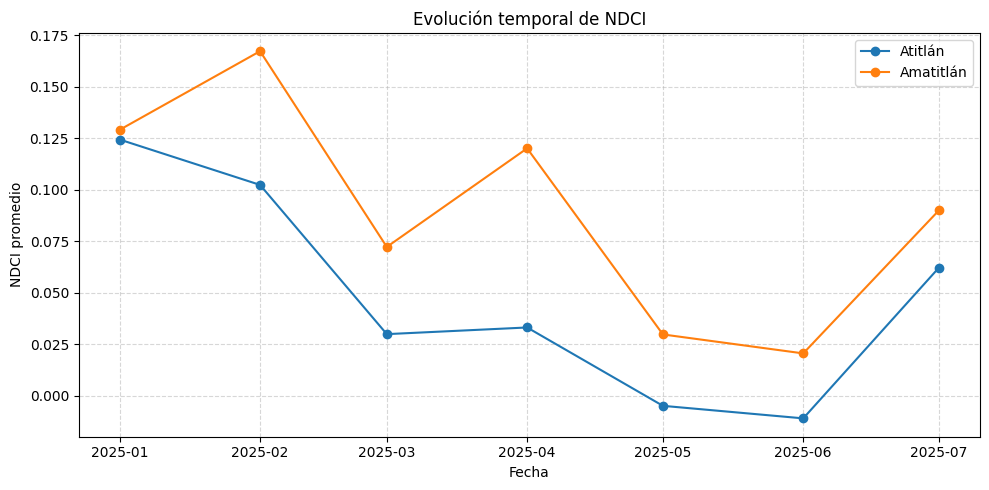

In [53]:
# Ejercicio 6

def process_tif_folder(folder):
    ndci_data = {}
    ndvi_data = {}
    ndwi_data = {}

    for tif_path in Path(folder).glob("*.tif"):
        date = parse_date_from_name(tif_path.name)
        if not date:
            continue
        with rasterio.open(tif_path) as src:
            red = normalize_if_needed(src.read(1))
            b5 = normalize_if_needed(src.read(2))
            green = normalize_if_needed(src.read(3))
            nir = normalize_if_needed(src.read(4))

            # Índices
            ndci_val = compute_index(b5 - red, b5 + red)
            ndvi_val = compute_index(nir - red, nir + red)
            ndwi_val = compute_index(green - nir, green + nir)

            ndci_data[date] = ndci_val
            ndvi_data[date] = ndvi_val
            ndwi_data[date] = ndwi_val

    return ndci_data, ndvi_data, ndwi_data

ndci_atl, ndvi_atl, ndwi_atl = process_tif_folder("./imagenes/NDCI_Atitlan")
ndci_ama, ndvi_ama, ndwi_ama = process_tif_folder("./imagenes/NDCI_Amatitlan")

# Media por fecha
def mean_by_date(index_dict):
    rows = []
    for d, arr in index_dict.items():
        arr_clip = np.clip(arr, -1.0, 1.0)
        rows.append({"date": pd.to_datetime(d), "mean": np.nanmean(arr_clip)})
    return pd.DataFrame(rows).sort_values("date").set_index("date")

ndci_atl_series = mean_by_date(ndci_atl)
ndci_ama_series = mean_by_date(ndci_ama)

print(ndci_atl_series.head())
print(ndci_ama_series.head())

# Graficos
plt.figure(figsize=(10, 5))
plt.plot(ndci_atl_series.index, ndci_atl_series["mean"], marker="o", label="Atitlán")
plt.plot(ndci_ama_series.index, ndci_ama_series["mean"], marker="o", label="Amatitlán")
plt.title("Evolución temporal de NDCI")
plt.xlabel("Fecha")
plt.ylabel("NDCI promedio")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("./imagenes/ndci_evolucion.png", dpi=150)
plt.show()



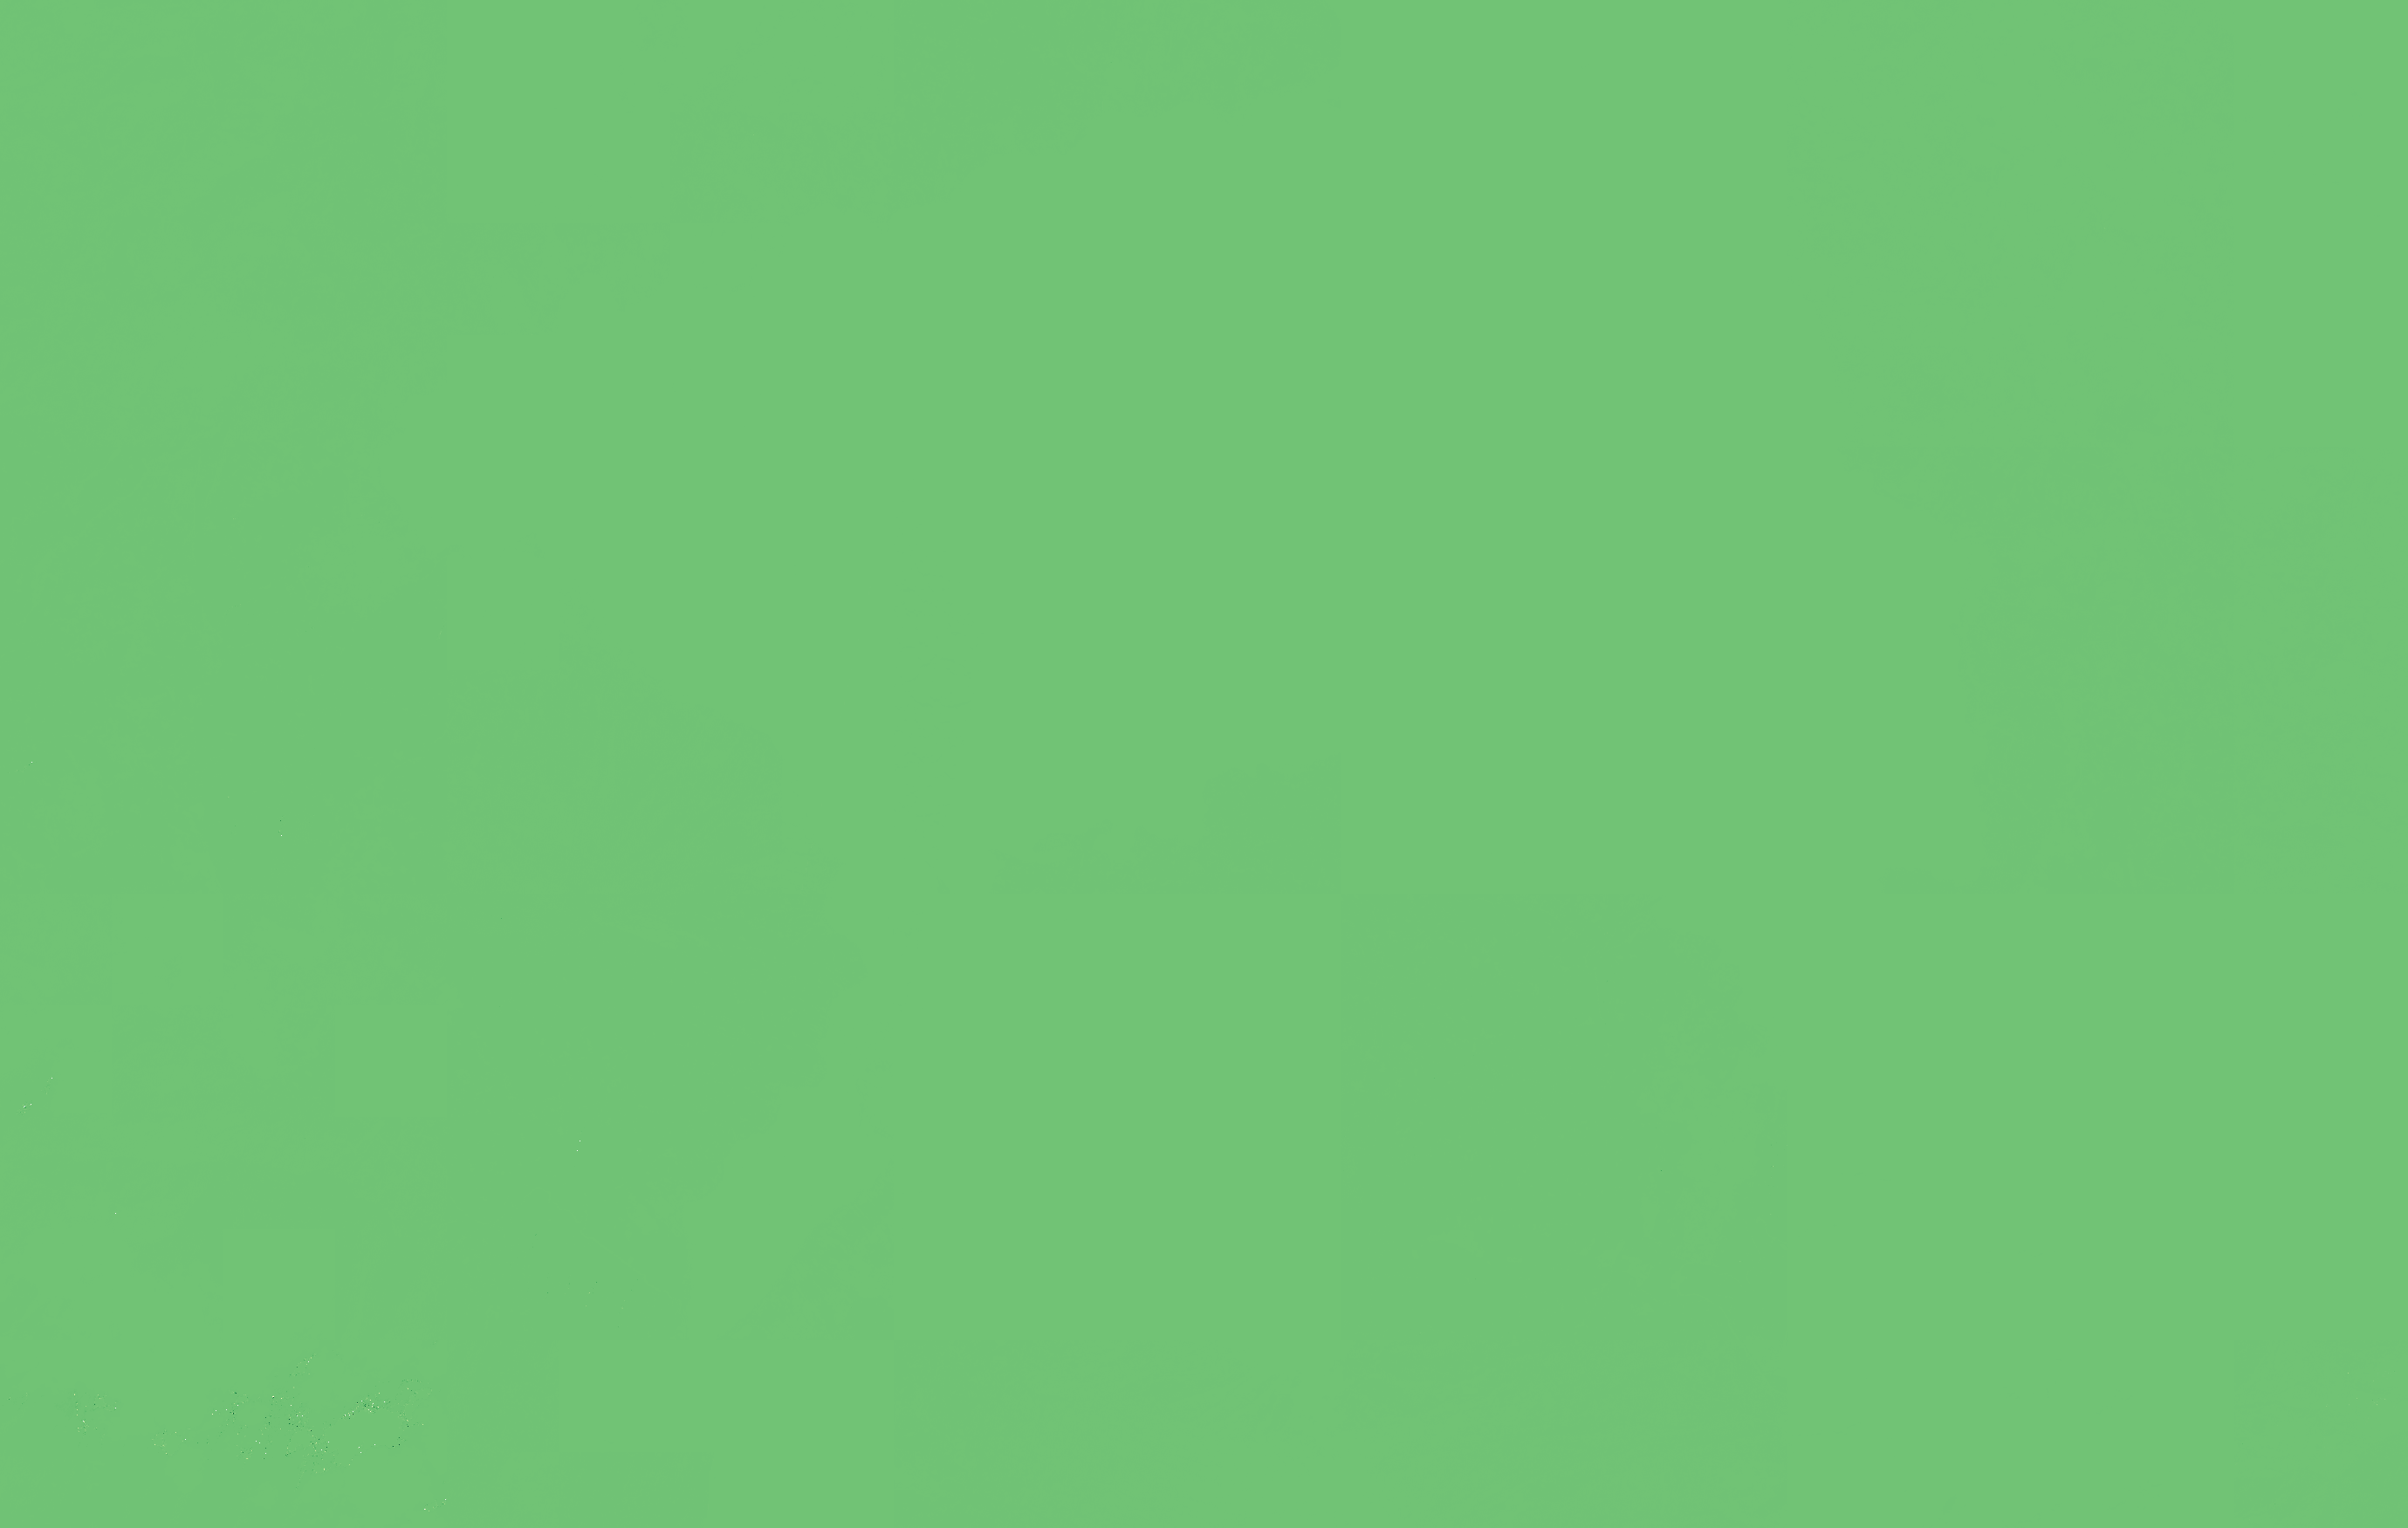

In [72]:
def crear_mapa_interactivo_con_geojson(ndci_array, raster_path, bbox, geojson_obj, opacity=0.6):
    # Centro del mapa
    lat_centro = (bbox["north"] + bbox["south"]) / 2
    lon_centro = (bbox["east"] + bbox["west"]) / 2

    m = folium.Map(location=[lat_centro, lon_centro], zoom_start=12)

    # Normalización y colormap para el ráster
    norm = colors.Normalize(vmin=np.nanmin(ndci_array), vmax=np.nanmax(ndci_array))
    colormap = plt.colormaps.get_cmap('YlGn')
    img = (colormap(norm(ndci_array)) * 255).astype(np.uint8)
    pil_img = Image.fromarray(img, mode='RGBA')

    # Codificar la imagen en base64 para folium
    buffered = io.BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    img_url = f"data:image/png;base64,{img_str}"

    # Añadir ráster como overlay en los bounds del bbox
    folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=[[bbox["south"], bbox["west"]], [bbox["north"], bbox["east"]]],
        opacity=opacity,
        name="NDCI"
    ).add_to(m)

    # Añadir geojson con borde del lago
    folium.GeoJson(
        geojson_obj,
        name="Lago",
        style_function=lambda feature: {
            'fillColor': 'transparent',
            'color': 'blue',
            'weight': 3,
            'opacity': 0.7
        }
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)
with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

# Calcular bbox 
def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

fecha = list(ndci_atl.keys())[0]
if isinstance(fecha, str):
    fecha_dt = pd.to_datetime(fecha)
else:
    fecha_dt = fecha

ruta_tif_atitlan = f"./imagenes/NDCI_Atitlan/openEO_{fecha_dt.strftime('%Y-%m-%d')}Z.tif"

mapa_atitlan = crear_mapa_interactivo_con_geojson(
    ndci_array=ndci_atl[fecha],
    raster_path=ruta_tif_atitlan,
    bbox=bbox_atitlan,
    geojson_obj=atitlan_geo,
    opacity=0.6
)
mapa_atitlan  



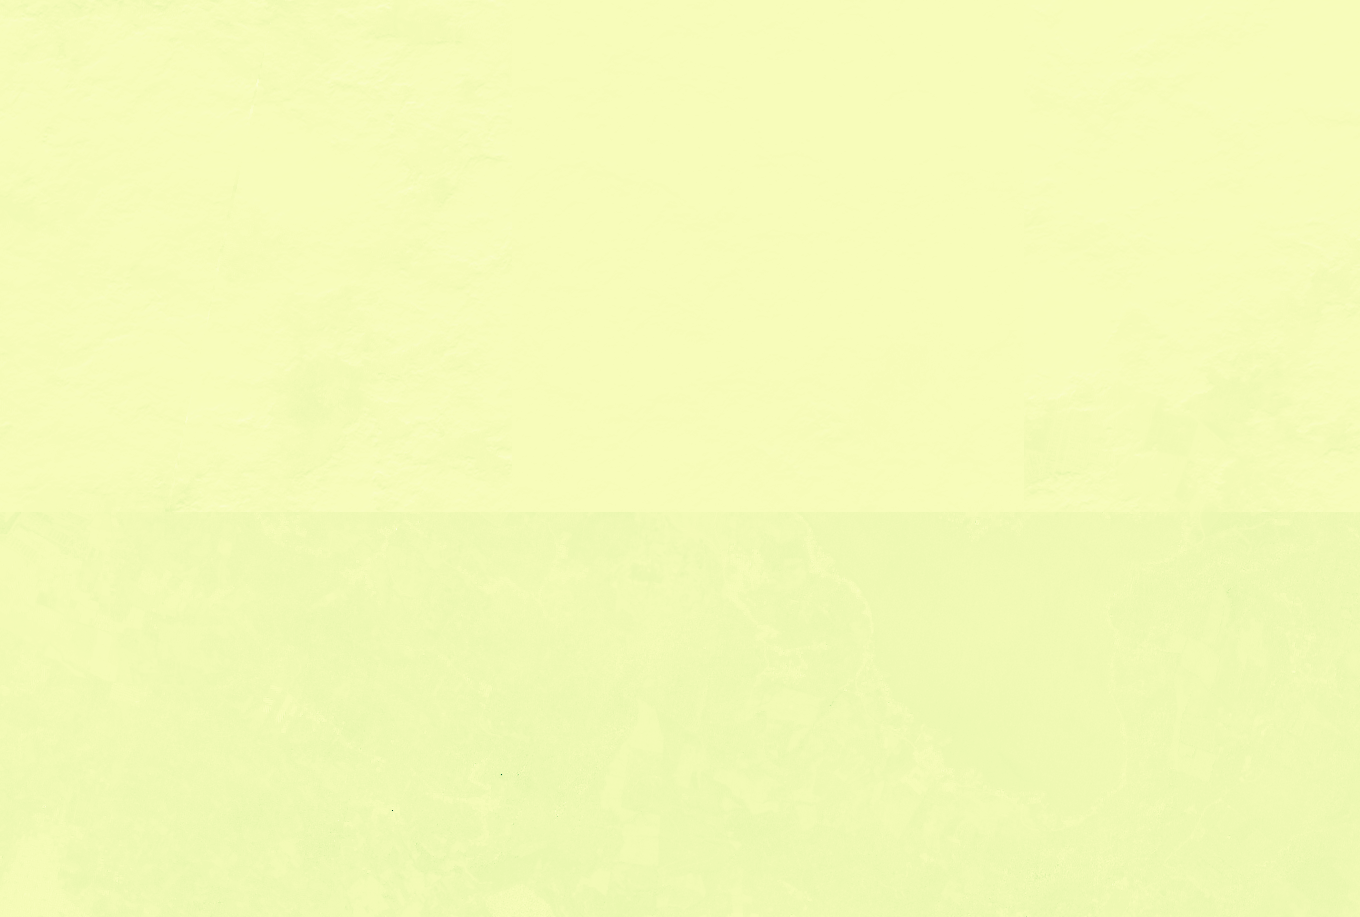

In [73]:
fecha_ama = list(ndci_ama.keys())[0]
if isinstance(fecha_ama, str):
    fecha_ama_dt = pd.to_datetime(fecha_ama)
else:
    fecha_ama_dt = fecha_ama

ruta_tif_amatitlan = f"./imagenes/NDCI_Amatitlan/openEO_{fecha_ama_dt.strftime('%Y-%m-%d')}Z.tif"

mapa_amatitlan = crear_mapa_interactivo_con_geojson(
    ndci_array=ndci_ama[fecha_ama],
    raster_path=ruta_tif_amatitlan,
    bbox=bbox_amatitlan,
    geojson_obj=amatitlan_geo,
    opacity=0.6
)
mapa_amatitlan

In [54]:
# Ejercicio 8
def correlation_analysis(index1, index2):
    vals1 = []
    vals2 = []
    for d in index1:
        if d in index2:
            vals1.append(np.nanmean(index1[d]))
            vals2.append(np.nanmean(index2[d]))
    return np.corrcoef(vals1, vals2)[0, 1]

corr_atl_ndvi = correlation_analysis(ndci_atl, ndvi_atl)
corr_atl_ndwi = correlation_analysis(ndci_atl, ndwi_atl)
corr_ama_ndvi = correlation_analysis(ndci_ama, ndvi_ama)
corr_ama_ndwi = correlation_analysis(ndci_ama, ndwi_ama)

print("Correlación Atitlán NDCI-NDVI:", corr_atl_ndvi)
print("Correlación Atitlán NDCI-NDWI:", corr_atl_ndwi)
print("Correlación Amatitlán NDCI-NDVI:", corr_ama_ndvi)
print("Correlación Amatitlán NDCI-NDWI:", corr_ama_ndwi)

Correlación Atitlán NDCI-NDVI: 0.8959395268402536
Correlación Atitlán NDCI-NDWI: -0.9837244234954823
Correlación Amatitlán NDCI-NDVI: 0.9487929892909243
Correlación Amatitlán NDCI-NDWI: -0.8802192978140633
